# EE 451: Communications Systems
## Lesson 6 — Introduction to Digital Communications: Binary ASK

### Learning Objectives
By the end of this lesson, you will be able to:
- Explain Binary Amplitude Shift Keying (ASK) as the digital counterpart to analog AM
- Analyze On-Off Keying (OOK) modulation and sketch its waveform
- Derive and calculate the spectrum and bandwidth of binary ASK signals
- Compare spectral characteristics of analog AM and digital ASK
- Describe coherent and non-coherent ASK demodulation
- Explain the superheterodyne receiver architecture

### Textbook Reference
Haykin & Moher, Chapter 7.1–7.2

In [1]:
# Setup: Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import butter, filtfilt

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 2

print("Setup complete! NumPy version:", np.__version__)

Setup complete! NumPy version: 2.4.1


## 1. From Analog AM to Digital ASK

In Lesson 5, we studied **analog** amplitude modulation — a continuous message $m(t)$ modulates a carrier.
Now we make the leap to **digital** communications: the message is a sequence of **bits**.

| Property | Analog AM | Binary ASK |
|----------|-----------|------------|
| Message | Continuous $m(t)$ | Discrete bits $\{b_n\} \in \{0, 1\}$ |
| Amplitude | Varies continuously | Two levels (on/off for OOK) |
| Bandwidth | $2B$ ($B$ = message BW) | $2R_b$ ($R_b$ = bit rate) |
| Demodulation | Envelope or coherent | Threshold + sampling |

**On-Off Keying (OOK)** is the simplest form of ASK:
- Bit "1" $\rightarrow$ transmit carrier: $s(t) = A\cos(2\pi f_c t)$
- Bit "0" $\rightarrow$ silence: $s(t) = 0$

**Applications:** RFID tags, infrared remote controls, legacy wireless systems, and the foundation for understanding QAM (WiFi, LTE).

**Key parameters:**
- Bit duration: $T_b$ seconds
- Bit rate: $R_b = 1/T_b$ bits/second
- Carrier frequency: $f_c \gg R_b$

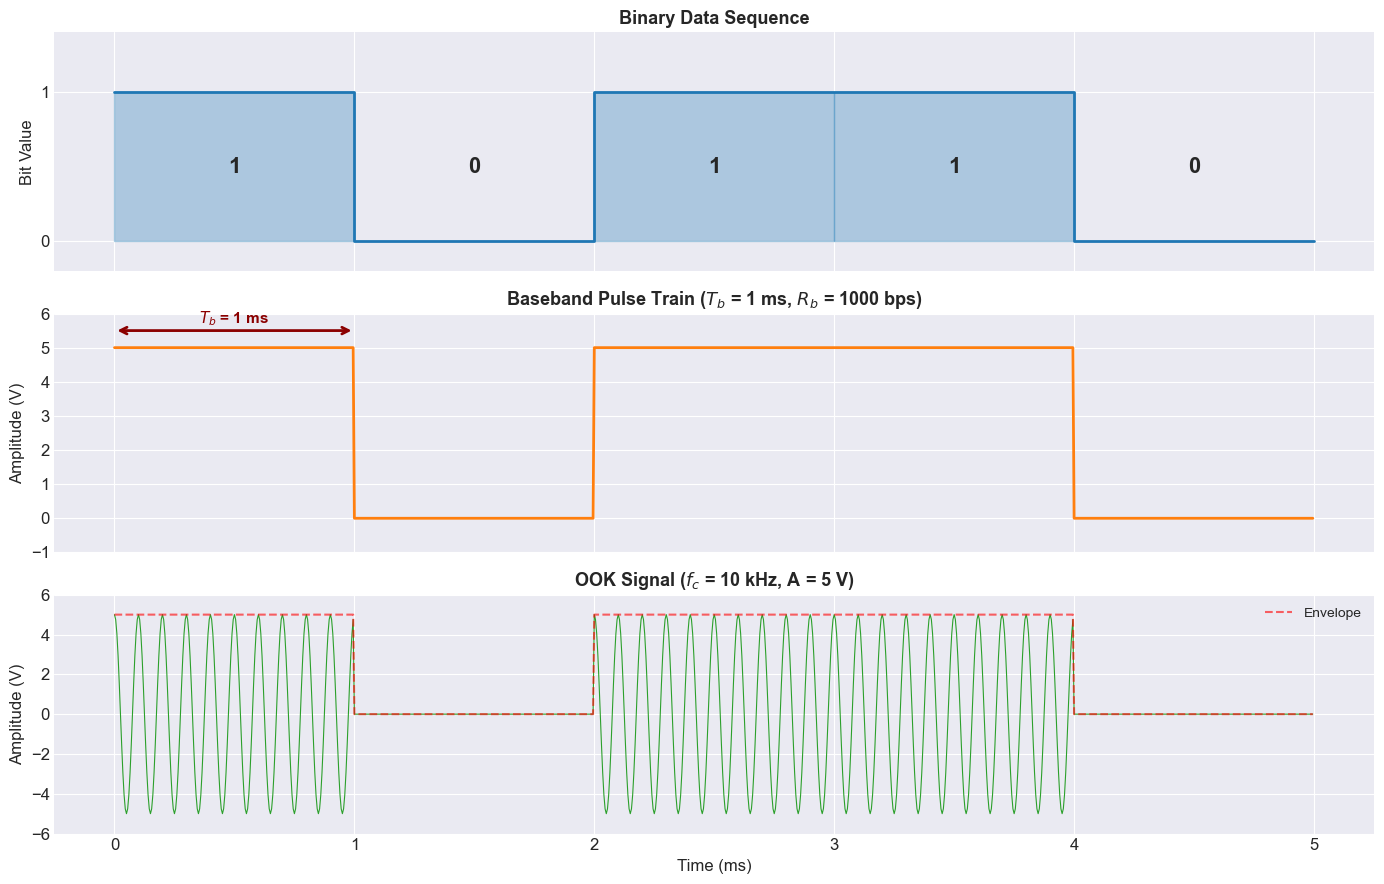

OOK Worked Example (HW2 Problem 6 parameters):
  Data: [np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0)]
  Bit rate: Rb = 1000 bps  =>  Tb = 1 ms
  Carrier: fc = 10 kHz, A = 5 V
  Carrier cycles per bit: fc / Rb = 10
  OOK expression for bit '1': s(t) = 5 cos(2π · 10000 · t) V
  OOK expression for bit '0': s(t) = 0


In [2]:
# =============================================================================
# Section 1: OOK Waveform Generation
# =============================================================================
# Parameters matching HW2 Problem 6
bits = np.array([1, 0, 1, 1, 0])  # Data sequence
Rb = 1000       # Bit rate (bps)
Tb = 1 / Rb     # Bit duration (s)
fc = 10000      # Carrier frequency (Hz)
A = 5           # Carrier amplitude for "1" (V)
num_bits = len(bits)

# Sampling
fs = 20 * fc    # Sampling rate
t_total = num_bits * Tb
t = np.arange(0, t_total, 1/fs)

# Generate baseband pulse train (rectangular pulses)
baseband = np.zeros(len(t))
for n in range(num_bits):
    start = int(n * Tb * fs)
    end = int((n + 1) * Tb * fs)
    if end > len(t):
        end = len(t)
    baseband[start:end] = bits[n]

# OOK signal: baseband × carrier
carrier = A * np.cos(2 * np.pi * fc * t)
s_ook = baseband * carrier

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# Bit stream
for n in range(num_bits):
    t_start = n * Tb * 1000
    t_end = (n + 1) * Tb * 1000
    axes[0].fill_between([t_start, t_end], 0, bits[n],
                         alpha=0.3, color='C0' if bits[n] else 'lightgray')
    axes[0].text((t_start + t_end) / 2, 0.5, str(bits[n]),
                 ha='center', va='center', fontsize=16, fontweight='bold')
axes[0].step(np.arange(num_bits + 1) * Tb * 1000,
             np.append(bits, bits[-1]), where='post', color='C0', linewidth=2)
axes[0].set_ylabel('Bit Value')
axes[0].set_title('Binary Data Sequence', fontsize=13, fontweight='bold')
axes[0].set_ylim(-0.2, 1.4)
axes[0].set_yticks([0, 1])

# Baseband pulse train
axes[1].plot(t * 1000, A * baseband, 'C1', linewidth=2)
axes[1].set_ylabel('Amplitude (V)')
axes[1].set_title(f'Baseband Pulse Train ($T_b$ = {Tb*1000:.0f} ms, $R_b$ = {Rb} bps)',
                   fontsize=13, fontweight='bold')
axes[1].set_ylim(-1, A + 1)
# Annotate Tb
axes[1].annotate('', xy=(0, A + 0.5), xytext=(Tb * 1000, A + 0.5),
                 arrowprops=dict(arrowstyle='<->', color='darkred', lw=2))
axes[1].text(Tb * 1000 / 2, A + 0.7, f'$T_b$ = {Tb*1000:.0f} ms',
             ha='center', fontsize=11, color='darkred', fontweight='bold')

# OOK modulated signal
axes[2].plot(t * 1000, s_ook, 'C2', linewidth=0.8)
axes[2].plot(t * 1000, A * baseband, 'r--', linewidth=1.5, alpha=0.6, label='Envelope')
axes[2].set_xlabel('Time (ms)')
axes[2].set_ylabel('Amplitude (V)')
axes[2].set_title(f'OOK Signal ($f_c$ = {fc/1000:.0f} kHz, A = {A} V)',
                   fontsize=13, fontweight='bold')
axes[2].set_ylim(-A - 1, A + 1)
axes[2].legend(fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

print("OOK Worked Example (HW2 Problem 6 parameters):")
print(f"  Data: {list(bits)}")
print(f"  Bit rate: Rb = {Rb} bps  =>  Tb = {Tb*1000:.0f} ms")
print(f"  Carrier: fc = {fc/1000:.0f} kHz, A = {A} V")
print(f"  Carrier cycles per bit: fc / Rb = {fc / Rb:.0f}")
print(f"  OOK expression for bit '1': s(t) = {A} cos(2\u03c0 \u00b7 {fc} \u00b7 t) V")
print(f"  OOK expression for bit '0': s(t) = 0")

## 2. Spectrum of Binary ASK

A random binary data stream is a **rectangular pulse train**, and rectangular pulses have a **sinc-shaped spectrum**.

**Baseband (unmodulated):**
- Each bit is a rectangular pulse of duration $T_b$
- Single pulse spectrum: $P(f) = T_b \operatorname{sinc}(f T_b)$
- Power spectral density (continuous part): $S_{bb}(f) \propto T_b^2 \operatorname{sinc}^2(f T_b)$
- The unipolar signal $\{0, A\}$ also has a **DC component** (mean $A/2$), producing a delta at $f = 0$
- First null at $f = R_b = 1/T_b$
- **Baseband bandwidth: $B = R_b$** (one-sided, from DC to first null)

**Modulated ASK** (apply modulation theorem — shift to carrier):

$$S_{\text{ASK}}(f) \propto \operatorname{sinc}^2[(f - f_c) T_b] + \operatorname{sinc}^2[(f + f_c) T_b]$$

- Main lobe centered at $\pm f_c$, spanning from $f_c - R_b$ to $f_c + R_b$
- The DC component shifts to a **carrier line** at $f_c$ (OOK carrier is *not* suppressed)

$$\boxed{\text{ASK null-to-null bandwidth} = 2R_b = 2B}$$

**Modulation doubles the bandwidth:** baseband $B = R_b$ becomes RF bandwidth $2B = 2R_b$.
This is the **same** relationship as DSB AM: message bandwidth $B$ → RF bandwidth $2B$.

*Convention: $\operatorname{sinc}(x) = \sin(\pi x)/(\pi x)$ per Haykin & Moher Eq. 2.9*

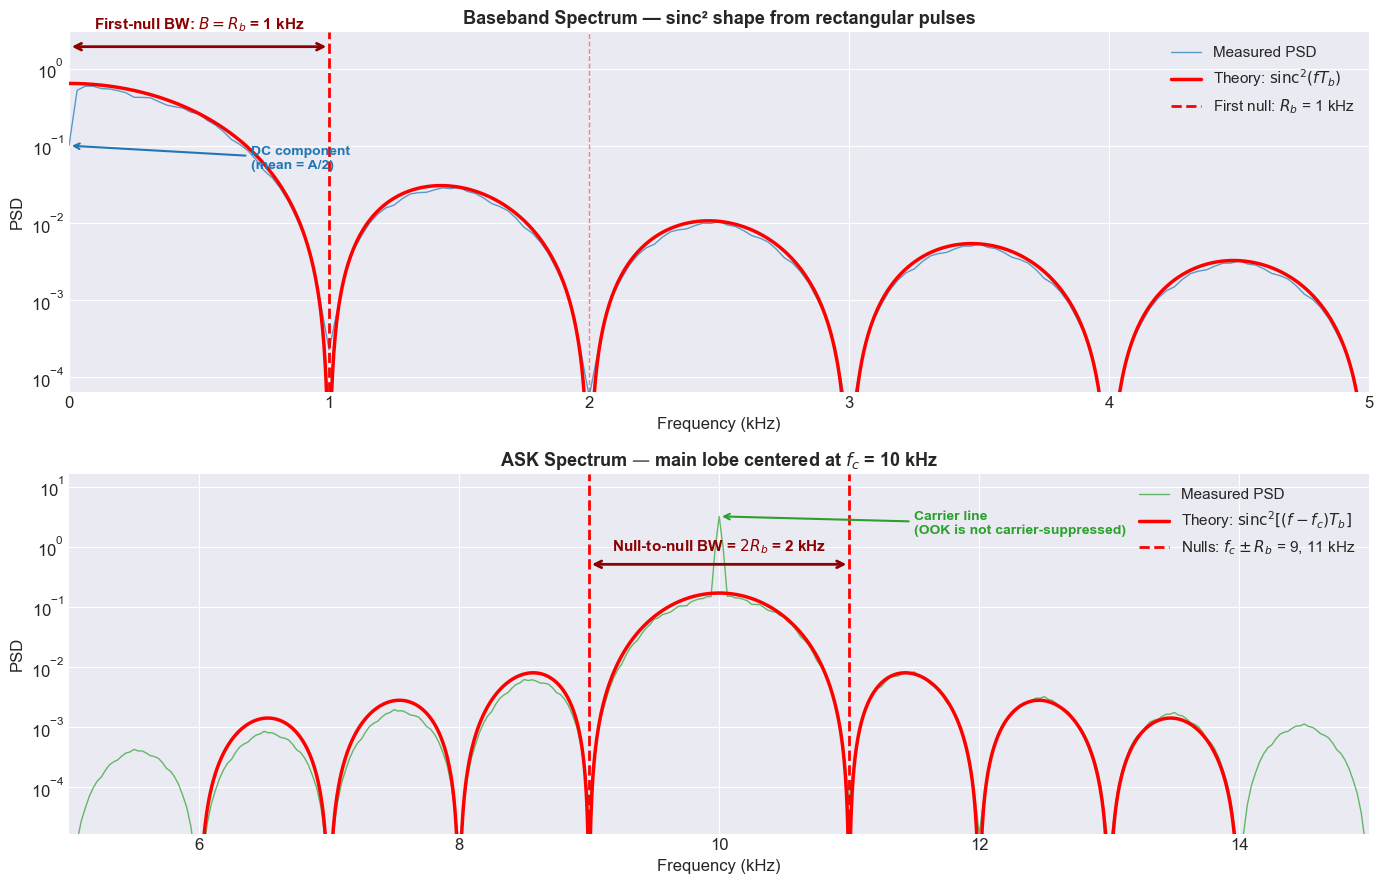

ASK Spectral Analysis:
  Bit rate: Rb = 1000 bps  =>  Tb = 1 ms
  Baseband first-null BW: B = Rb = 1 kHz
  Modulated ASK main lobe: 9 kHz to 11 kHz
  Modulated ASK null-to-null BW: 2Rb = 2 kHz
  Note: Carrier spike at fc (unipolar baseband has DC => carrier not suppressed)
  Key insight: Modulation doubles BW (baseband B = Rb => RF BW = 2Rb = 2B)


In [3]:
# =============================================================================
# Section 2: ASK Spectral Analysis
# =============================================================================
# Use a long random bit sequence + Welch's method for a smooth PSD estimate
from scipy.signal import welch

np.random.seed(42)
num_bits_spec = 2000
bits_rand = np.random.randint(0, 2, num_bits_spec)

Rb = 1000
Tb = 1 / Rb
fc = 10000
A = 5
fs = 20 * fc
samples_per_bit = int(Tb * fs)

# Baseband pulse train (vectorized)
bb = np.repeat(A * bits_rand.astype(float), samples_per_bit)
N_spec = len(bb)
t_spec = np.arange(N_spec) / fs

# ASK modulated signal
s_ask = bb * np.cos(2 * np.pi * fc * t_spec)

# PSD via Welch (nperseg ~ several bit periods for good freq resolution)
nperseg = samples_per_bit * 32
f_bb, Pxx_bb = welch(bb, fs=fs, nperseg=nperseg, scaling='spectrum')
f_ask, Pxx_ask = welch(s_ask, fs=fs, nperseg=nperseg, scaling='spectrum')
df_bb = f_bb[1] - f_bb[0]
df_ask = f_ask[1] - f_ask[0]

# --- Theoretical sinc² envelopes, scaled to match the CONTINUOUS part of PSD ---
# Baseband: scale at f = Rb/2 (midpoint of main lobe, away from DC spike)
f_theory = np.linspace(0.01, 5 * Rb, 2000)
sinc_env = np.sinc(f_theory * Tb)**2  # unit-amplitude sinc²
idx_half_Rb = np.argmin(np.abs(f_bb - Rb / 2))
scale_bb = Pxx_bb[idx_half_Rb] / np.sinc(0.5)**2   # sinc(0.5) = sinc(Rb/2 * Tb)
sinc_env_scaled = sinc_env * scale_bb

# ASK: scale at f = fc + Rb/2 (halfway up the main lobe, away from carrier spike)
f_theory_ask = np.linspace(fc - 4 * Rb, fc + 4 * Rb, 2000)
sinc_env_ask = np.sinc((f_theory_ask - fc) * Tb)**2
idx_offset = np.argmin(np.abs(f_ask - (fc + Rb / 2)))
scale_ask = Pxx_ask[idx_offset] / np.sinc(0.5)**2
sinc_env_ask_scaled = sinc_env_ask * scale_ask

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# --- Baseband spectrum ---
axes[0].semilogy(f_bb / 1000, Pxx_bb, 'C0', linewidth=1, alpha=0.7, label='Measured PSD')
axes[0].semilogy(f_theory / 1000, sinc_env_scaled, 'r-', linewidth=2.5,
                 label=r'Theory: $\mathrm{sinc}^2(fT_b)$')
axes[0].axvline(Rb / 1000, color='red', linestyle='--', linewidth=2,
                label=f'First null: $R_b$ = {Rb/1000:.0f} kHz')
axes[0].axvline(2 * Rb / 1000, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_xlim(0, 5)
y_main = scale_bb  # continuous PSD peak (without DC spike)
axes[0].set_ylim(y_main * 1e-4, Pxx_bb.max() * 5)
axes[0].set_xlabel('Frequency (kHz)')
axes[0].set_ylabel('PSD')
axes[0].set_title('Baseband Spectrum — sinc² shape from rectangular pulses',
                   fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11, loc='upper right')
# Annotate DC spike
axes[0].annotate('DC component\n(mean = A/2)',
                 xy=(0, Pxx_bb[0]), xytext=(0.7, Pxx_bb[0] * 0.5),
                 fontsize=10, color='C0', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='C0', lw=1.5))
# Annotate first-null bandwidth
axes[0].annotate('', xy=(0, y_main * 3), xytext=(Rb / 1000, y_main * 3),
                 arrowprops=dict(arrowstyle='<->', color='darkred', lw=2))
axes[0].text(Rb / 2000, y_main * 5, f'First-null BW: $B = R_b$ = {Rb/1000:.0f} kHz',
             ha='center', fontsize=11, color='darkred', fontweight='bold')

# --- ASK spectrum ---
axes[1].semilogy(f_ask / 1000, Pxx_ask, 'C2', linewidth=1, alpha=0.7, label='Measured PSD')
axes[1].semilogy(f_theory_ask / 1000, sinc_env_ask_scaled, 'r-', linewidth=2.5,
                 label=r'Theory: $\mathrm{sinc}^2[(f - f_c)T_b]$')
axes[1].axvline((fc - Rb) / 1000, color='red', linestyle='--', linewidth=2,
                label=f'Nulls: $f_c \\pm R_b$ = {(fc-Rb)/1000:.0f}, {(fc+Rb)/1000:.0f} kHz')
axes[1].axvline((fc + Rb) / 1000, color='red', linestyle='--', linewidth=2)
axes[1].set_xlim(5, 15)
y_main_ask = scale_ask  # continuous PSD peak (without carrier spike)
axes[1].set_ylim(y_main_ask * 1e-4, Pxx_ask.max() * 5)
axes[1].set_xlabel('Frequency (kHz)')
axes[1].set_ylabel('PSD')
axes[1].set_title(f'ASK Spectrum — main lobe centered at $f_c$ = {fc/1000:.0f} kHz',
                   fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11, loc='upper right')
# Annotate carrier spike
carrier_idx = np.argmin(np.abs(f_ask - fc))
axes[1].annotate('Carrier line\n(OOK is not carrier-suppressed)',
                 xy=(fc / 1000, Pxx_ask[carrier_idx]),
                 xytext=(fc / 1000 + 1.5, Pxx_ask[carrier_idx] * 0.5),
                 fontsize=10, color='C2', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='C2', lw=1.5))
# Annotate BW
axes[1].annotate('', xy=((fc - Rb) / 1000, y_main_ask * 3),
                 xytext=((fc + Rb) / 1000, y_main_ask * 3),
                 arrowprops=dict(arrowstyle='<->', color='darkred', lw=2))
axes[1].text(fc / 1000, y_main_ask * 5, f'Null-to-null BW = $2R_b$ = {2*Rb/1000:.0f} kHz',
             ha='center', fontsize=11, color='darkred', fontweight='bold')

plt.tight_layout()
plt.show()

print("ASK Spectral Analysis:")
print(f"  Bit rate: Rb = {Rb} bps  =>  Tb = {Tb*1000:.0f} ms")
print(f"  Baseband first-null BW: B = Rb = {Rb/1000:.0f} kHz")
print(f"  Modulated ASK main lobe: {(fc-Rb)/1000:.0f} kHz to {(fc+Rb)/1000:.0f} kHz")
print(f"  Modulated ASK null-to-null BW: 2Rb = {2*Rb/1000:.0f} kHz")
print(f"  Note: Carrier spike at fc (unipolar baseband has DC => carrier not suppressed)")
print(f"  Key insight: Modulation doubles BW (baseband B = Rb => RF BW = 2Rb = 2B)")

## 3. Analog AM vs. Digital ASK — Side by Side

AM and ASK are fundamentally the **same modulation technique** applied to different message types.
Both encode information in the carrier amplitude; both produce the same spectral structure.

| Property | Analog AM | Binary ASK (OOK) |
|----------|-----------|------------------|
| Message | Continuous $m(t)$ | Bits $\{0, 1\}$ |
| Spectrum shape | Smooth (follows $M(f)$) | Sinc-shaped (rectangular pulses) |
| Bandwidth | $2B$ | $2R_b$ |
| Demod (simple) | Envelope detector | Envelope + threshold |
| Demod (optimal) | Coherent | Matched filter |
| Info measure | Analog fidelity (SNR) | Bit error rate (BER) |

**Why both can use envelope detection:** In both cases, the message information is encoded in the
envelope $A(t)$. An envelope detector extracts $|A(t)|$ regardless of whether $A(t)$ is continuous
(AM) or binary (ASK).

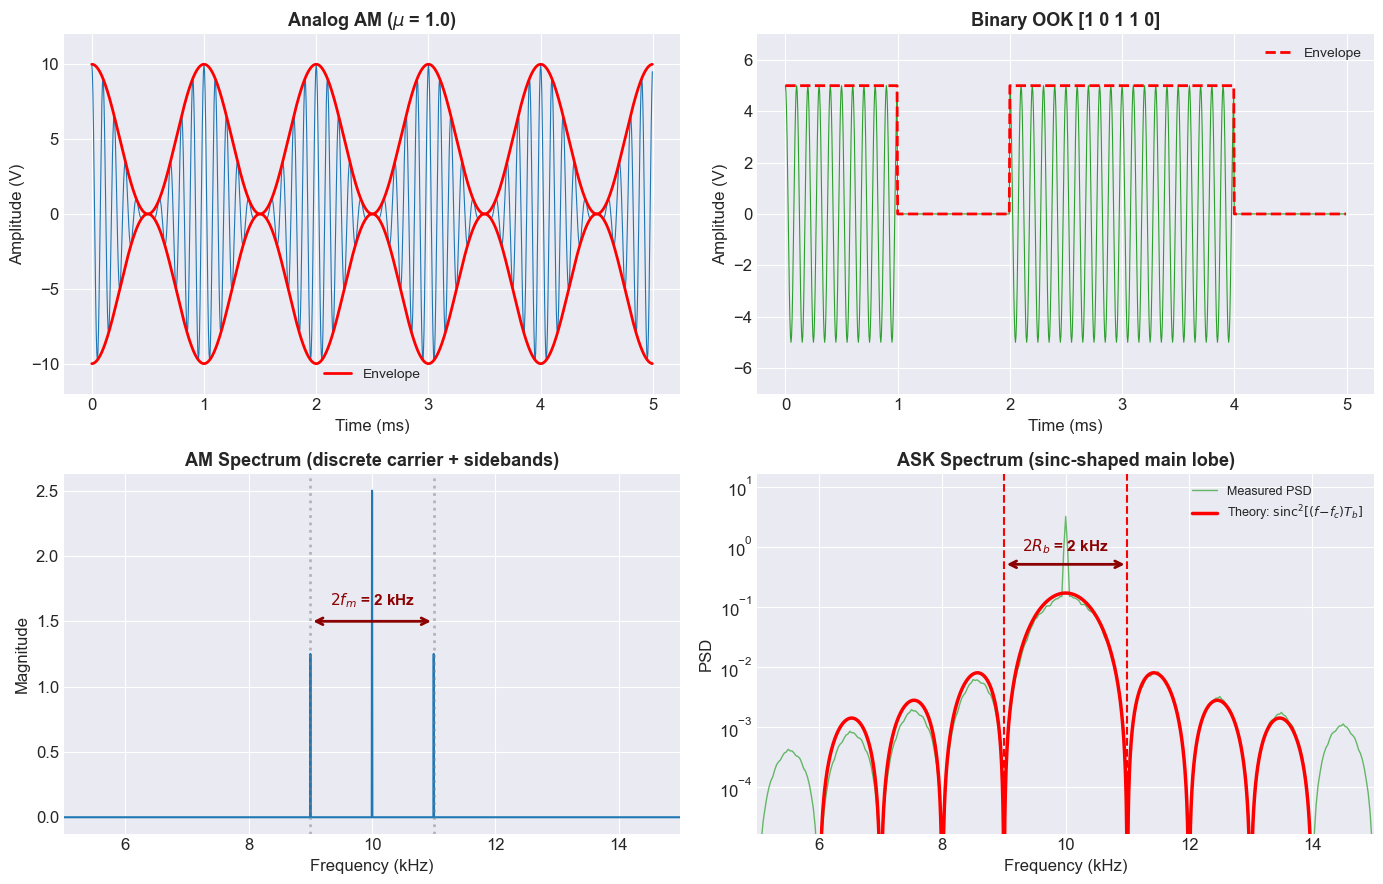

AM vs ASK Comparison:
  AM: message BW = fm = 1 kHz  =>  RF BW = 2fm = 2 kHz
  ASK: bit rate = Rb = 1 kbps  =>  RF BW = 2Rb = 2 kHz
  Same bandwidth formula!  BW = 2 × (message bandwidth or bit rate)

  Key differences:
    AM spectrum: discrete lines (carrier + sidebands for single tone)
    ASK spectrum: continuous sinc² shape (random data)
    Both can use envelope detection (info is in the amplitude)


In [4]:
# =============================================================================
# Section 3: AM vs ASK — Side-by-Side Comparison
# =============================================================================
from scipy.signal import welch as welch_psd

fm = 1000       # Message frequency (same as Rb for comparison)
fc = 10000      # Carrier frequency
Ac = 5          # Carrier amplitude
mu = 1.0        # Full modulation for AM
Rb = 1000
Tb = 1 / Rb
fs = 20 * fc

# -- AM signal (time domain) --
T_am = 0.005    # 5 ms
t_am = np.arange(0, T_am, 1/fs)
m_am = np.cos(2 * np.pi * fm * t_am)
s_am = Ac * (1 + mu * m_am) * np.cos(2 * np.pi * fc * t_am)
env_am = Ac * (1 + mu * m_am)

# -- ASK signal (time domain) --
bits_cmp = np.array([1, 0, 1, 1, 0])
T_ask = len(bits_cmp) * Tb
t_ask = np.arange(0, T_ask, 1/fs)
bb_cmp = np.zeros(len(t_ask))
for n in range(len(bits_cmp)):
    s_idx = int(n * Tb * fs)
    e_idx = min(int((n + 1) * Tb * fs), len(t_ask))
    bb_cmp[s_idx:e_idx] = bits_cmp[n]
s_ask_cmp = Ac * bb_cmp * np.cos(2 * np.pi * fc * t_ask)

# -- AM spectrum (deterministic signal — FFT gives clean discrete lines) --
T_long = 0.2
t_long = np.arange(0, T_long, 1/fs)
N_long = len(t_long)
freqs_long = fftfreq(N_long, 1/fs)
pos_long = freqs_long >= 0

m_long = np.cos(2 * np.pi * fm * t_long)
s_am_long = Ac * (1 + mu * m_long) * np.cos(2 * np.pi * fc * t_long)
AM_spec = np.abs(fft(s_am_long))[pos_long] / N_long
f_long = freqs_long[pos_long]

# -- ASK spectrum (random data — Welch PSD for smooth sinc² shape) --
np.random.seed(42)
num_bits_cmp = 2000
bits_long = np.random.randint(0, 2, num_bits_cmp)
samples_per_bit = int(Tb * fs)
bb_long = np.repeat(Ac * bits_long.astype(float), samples_per_bit)
N_ask = len(bb_long)
t_ask_long = np.arange(N_ask) / fs
s_ask_long = bb_long * np.cos(2 * np.pi * fc * t_ask_long)

nperseg = samples_per_bit * 32
f_ask_psd, Pxx_ask = welch_psd(s_ask_long, fs=fs, nperseg=nperseg, scaling='spectrum')

# Theoretical sinc² envelope, scaled at fc + Rb/2 (away from carrier spike)
f_theory = np.linspace(fc - 4 * Rb, fc + 4 * Rb, 2000)
sinc_env = np.sinc((f_theory - fc) * Tb)**2
idx_offset = np.argmin(np.abs(f_ask_psd - (fc + Rb / 2)))
scale_ask = Pxx_ask[idx_offset] / np.sinc(0.5)**2
sinc_env_scaled = sinc_env * scale_ask

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# AM time domain
axes[0, 0].plot(t_am * 1000, s_am, 'C0', linewidth=0.8)
axes[0, 0].plot(t_am * 1000, env_am, 'r-', linewidth=2, label='Envelope')
axes[0, 0].plot(t_am * 1000, -env_am, 'r-', linewidth=2)
axes[0, 0].set_title('Analog AM ($\\mu$ = 1.0)', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Amplitude (V)')
axes[0, 0].set_xlabel('Time (ms)')
axes[0, 0].legend(fontsize=10)
axes[0, 0].set_ylim(-12, 12)

# ASK time domain
axes[0, 1].plot(t_ask * 1000, s_ask_cmp, 'C2', linewidth=0.8)
axes[0, 1].plot(t_ask * 1000, Ac * bb_cmp, 'r--', linewidth=2, label='Envelope')
axes[0, 1].set_title('Binary OOK [1 0 1 1 0]', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Amplitude (V)')
axes[0, 1].set_xlabel('Time (ms)')
axes[0, 1].legend(fontsize=10)
axes[0, 1].set_ylim(-7, 7)

# AM spectrum (FFT — clean discrete lines)
axes[1, 0].plot(f_long / 1000, AM_spec, 'C0', linewidth=1.5)
axes[1, 0].set_title('AM Spectrum (discrete carrier + sidebands)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Frequency (kHz)')
axes[1, 0].set_ylabel('Magnitude')
axes[1, 0].set_xlim(5, 15)
axes[1, 0].axvline((fc - fm) / 1000, color='gray', linestyle=':', alpha=0.5)
axes[1, 0].axvline((fc + fm) / 1000, color='gray', linestyle=':', alpha=0.5)
axes[1, 0].annotate('', xy=((fc - fm) / 1000, AM_spec.max() * 0.6),
                     xytext=((fc + fm) / 1000, AM_spec.max() * 0.6),
                     arrowprops=dict(arrowstyle='<->', color='darkred', lw=2))
axes[1, 0].text(fc / 1000, AM_spec.max() * 0.65, f'$2f_m$ = {2*fm/1000:.0f} kHz',
                ha='center', fontsize=11, color='darkred', fontweight='bold')

# ASK spectrum (Welch PSD — smooth sinc² with theoretical overlay)
axes[1, 1].semilogy(f_ask_psd / 1000, Pxx_ask, 'C2', linewidth=1, alpha=0.7,
                     label='Measured PSD')
axes[1, 1].semilogy(f_theory / 1000, sinc_env_scaled, 'r-', linewidth=2.5,
                     label=r'Theory: $\mathrm{sinc}^2[(f\!-\!f_c)T_b]$')
axes[1, 1].axvline((fc - Rb) / 1000, color='red', linestyle='--', linewidth=1.5)
axes[1, 1].axvline((fc + Rb) / 1000, color='red', linestyle='--', linewidth=1.5)
axes[1, 1].set_title('ASK Spectrum (sinc-shaped main lobe)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Frequency (kHz)')
axes[1, 1].set_ylabel('PSD')
axes[1, 1].set_xlim(5, 15)
y_main = scale_ask
axes[1, 1].set_ylim(y_main * 1e-4, Pxx_ask.max() * 5)
axes[1, 1].annotate('', xy=((fc - Rb) / 1000, y_main * 3),
                     xytext=((fc + Rb) / 1000, y_main * 3),
                     arrowprops=dict(arrowstyle='<->', color='darkred', lw=2))
axes[1, 1].text(fc / 1000, y_main * 5, f'$2R_b$ = {2*Rb/1000:.0f} kHz',
                ha='center', fontsize=11, color='darkred', fontweight='bold')
axes[1, 1].legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

print("AM vs ASK Comparison:")
print(f"  AM: message BW = fm = {fm/1000:.0f} kHz  =>  RF BW = 2fm = {2*fm/1000:.0f} kHz")
print(f"  ASK: bit rate = Rb = {Rb/1000:.0f} kbps  =>  RF BW = 2Rb = {2*Rb/1000:.0f} kHz")
print(f"  Same bandwidth formula!  BW = 2 \u00d7 (message bandwidth or bit rate)")
print(f"\n  Key differences:")
print(f"    AM spectrum: discrete lines (carrier + sidebands for single tone)")
print(f"    ASK spectrum: continuous sinc\u00b2 shape (random data)")
print(f"    Both can use envelope detection (info is in the amplitude)")

## 4. ASK Demodulation

### Coherent Detection
1. Multiply received signal by local carrier: $r(t) \cdot 2\cos(2\pi f_c t)$
2. Lowpass filter to remove the $2f_c$ component
3. Sample at the center of each bit period: $t = nT_b + T_b/2$
4. Compare to threshold $\gamma$ (typically $A/2$ for OOK)
5. Decide: sample $> \gamma \Rightarrow$ bit 1, else bit 0

### Non-Coherent Detection (Envelope)
- Same envelope detector as AM (diode + RC)
- Simpler (no carrier sync needed), but worse noise performance

### Matched Filter (Optimal)
- Filter impulse response matched to pulse shape: $h(t) = p(T_b - t)$
- Maximizes SNR at the sampling instant
- For rectangular pulses: equivalent to **integrate-and-dump** over $T_b$

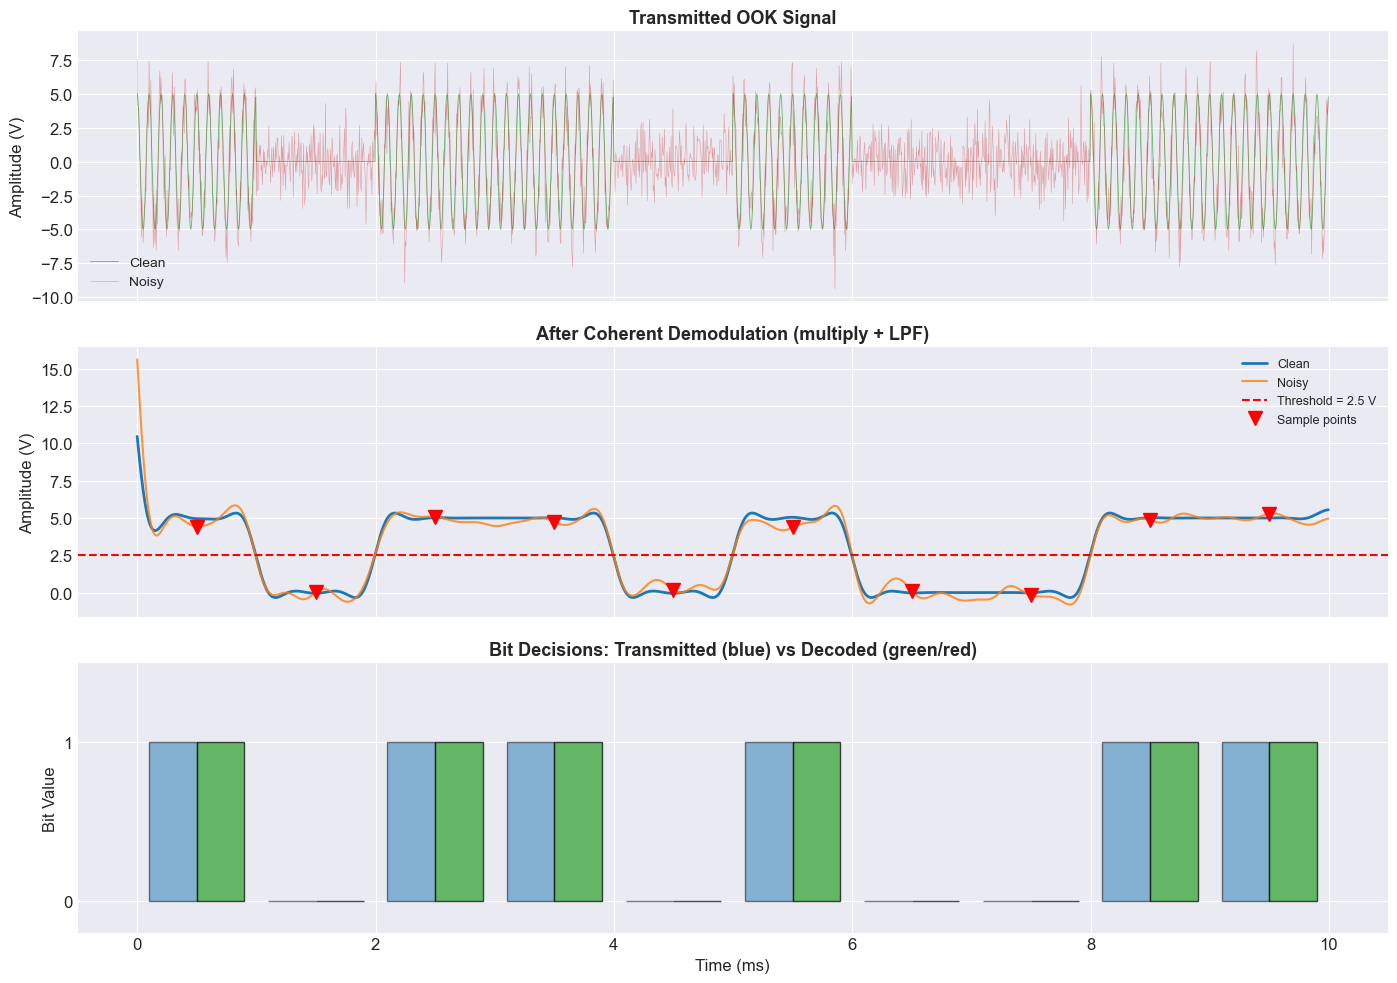

Coherent OOK Demodulation:
  Transmitted: [np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1)]
  Decoded:     [np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1)]
  Bit errors:  0/10
  Threshold:   2.5 V (midpoint between 0 and A)
  Noise std:   1.5 V

Demodulation steps:
  1. Multiply by 2cos(2π fc t) => shifts spectrum back to baseband
  2. Lowpass filter => removes 2fc component
  3. Sample at bit centers (t = nTb + Tb/2)
  4. Compare to threshold => decide 0 or 1


In [5]:
# =============================================================================
# Section 4: Coherent ASK Demodulation
# =============================================================================
# Transmit and demodulate with and without noise
bits_tx = np.array([1, 0, 1, 1, 0, 1, 0, 0, 1, 1])
num_bits_tx = len(bits_tx)
Rb = 1000
Tb = 1 / Rb
fc = 10000
A = 5
fs = 20 * fc

t_tx = np.arange(0, num_bits_tx * Tb, 1/fs)
N_tx = len(t_tx)

# Generate OOK
bb_tx = np.zeros(N_tx)
for n in range(num_bits_tx):
    s_idx = int(n * Tb * fs)
    e_idx = min(int((n + 1) * Tb * fs), N_tx)
    bb_tx[s_idx:e_idx] = bits_tx[n]
s_tx = A * bb_tx * np.cos(2 * np.pi * fc * t_tx)

# Add noise (two cases)
np.random.seed(7)
noise_std = 1.5
noise = noise_std * np.random.randn(N_tx)
s_noisy = s_tx + noise

# Coherent demodulation
def coherent_demod(rx, t, fc, fs, Rb, num_bits):
    """Coherent OOK demodulation: multiply, filter, sample, threshold."""
    Tb = 1 / Rb
    # Multiply by 2*carrier
    product = rx * 2 * np.cos(2 * np.pi * fc * t)
    # Lowpass filter
    nyq = fs / 2
    b, a = butter(4, Rb * 3 / nyq, btype='low')
    filtered = filtfilt(b, a, product)
    # Sample at bit centers
    samples = []
    for n in range(num_bits):
        idx = int((n + 0.5) * Tb * fs)
        if idx < len(filtered):
            samples.append(filtered[idx])
    samples = np.array(samples)
    # Threshold
    threshold = A / 2
    decisions = (samples > threshold).astype(int)
    return filtered, samples, decisions, threshold

# Demod clean signal
filt_clean, samp_clean, dec_clean, thresh = coherent_demod(
    s_tx, t_tx, fc, fs, Rb, num_bits_tx)

# Demod noisy signal
filt_noisy, samp_noisy, dec_noisy, _ = coherent_demod(
    s_noisy, t_tx, fc, fs, Rb, num_bits_tx)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Transmitted signal
axes[0].plot(t_tx * 1000, s_tx, 'C2', linewidth=0.6, alpha=0.7, label='Clean')
axes[0].plot(t_tx * 1000, s_noisy, 'C3', linewidth=0.4, alpha=0.4, label='Noisy')
axes[0].set_ylabel('Amplitude (V)')
axes[0].set_title('Transmitted OOK Signal', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# Demodulated (after LPF)
axes[1].plot(t_tx * 1000, filt_clean, 'C0', linewidth=2, label='Clean')
axes[1].plot(t_tx * 1000, filt_noisy, 'C1', linewidth=1.5, alpha=0.8, label='Noisy')
axes[1].axhline(thresh, color='red', linestyle='--', linewidth=1.5, label=f'Threshold = {thresh} V')
# Plot sample points
sample_times = [(n + 0.5) * Tb * 1000 for n in range(num_bits_tx)]
axes[1].plot(sample_times, samp_noisy, 'rv', markersize=10, label='Sample points')
axes[1].set_ylabel('Amplitude (V)')
axes[1].set_title('After Coherent Demodulation (multiply + LPF)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9, loc='upper right')

# Bit decisions
bar_width = Tb * 1000 * 0.8
for n in range(num_bits_tx):
    t_center = (n + 0.5) * Tb * 1000
    # Original bit
    color_tx = 'C0' if bits_tx[n] == 1 else 'lightgray'
    axes[2].bar(t_center - bar_width/4, bits_tx[n], width=bar_width/2,
               color=color_tx, alpha=0.5, edgecolor='black')
    # Decoded bit
    is_error = dec_noisy[n] != bits_tx[n]
    color_rx = 'red' if is_error else 'C2'
    axes[2].bar(t_center + bar_width/4, dec_noisy[n], width=bar_width/2,
               color=color_rx, alpha=0.7, edgecolor='black')

axes[2].set_xlabel('Time (ms)')
axes[2].set_ylabel('Bit Value')
axes[2].set_title('Bit Decisions: Transmitted (blue) vs Decoded (green/red)',
                   fontsize=13, fontweight='bold')
axes[2].set_ylim(-0.2, 1.5)
axes[2].set_yticks([0, 1])

plt.tight_layout()
plt.show()

errors = np.sum(dec_noisy != bits_tx)
print("Coherent OOK Demodulation:")
print(f"  Transmitted: {list(bits_tx)}")
print(f"  Decoded:     {list(dec_noisy)}")
print(f"  Bit errors:  {errors}/{num_bits_tx}")
print(f"  Threshold:   {thresh} V (midpoint between 0 and A)")
print(f"  Noise std:   {noise_std} V")
print(f"\nDemodulation steps:")
print(f"  1. Multiply by 2cos(2\u03c0 fc t) => shifts spectrum back to baseband")
print(f"  2. Lowpass filter => removes 2fc component")
print(f"  3. Sample at bit centers (t = nTb + Tb/2)")
print(f"  4. Compare to threshold => decide 0 or 1")

## 5. Superheterodyne Receiver

The **superheterodyne** ("superhet") is the dominant receiver architecture in AM/FM radios, WiFi, and cellular systems.

**Block diagram:**

```
Antenna → [RF Filter] → [Mixer ×] → [IF Filter] → [IF Amp] → [Demodulator]
                             ↑
                     [Local Oscillator]
                        f_LO (tunable)
```

**Key idea:** Convert the incoming RF signal to a **fixed** intermediate frequency (IF), where selectivity and amplification are easier. Only the LO is tuned when changing stations — the IF filter, IF amplifier, and demodulator all operate at a single fixed frequency.

**Frequency conversion (high-side injection):**

$$f_{\text{IF}} = f_{\text{LO}} - f_{\text{RF}} \quad\Longrightarrow\quad f_{\text{LO}} = f_{\text{RF}} + f_{\text{IF}}$$

### Why the image problem is unavoidable

The mixer is a **multiplier**. Multiplying the received signal by the local oscillator gives:

$$\cos(2\pi f_{\text{RF}} t) \cdot \cos(2\pi f_{\text{LO}} t) = \tfrac{1}{2}\bigl[\cos(2\pi \underbrace{(f_{\text{LO}} - f_{\text{RF}})}_{f_{\text{IF}}} t) + \cos(2\pi (f_{\text{LO}} + f_{\text{RF}}) t)\bigr]$$

The IF filter selects the difference term $|f_{\text{LO}} - f_{\text{RF}}|$. But **the absolute value makes the mixer blind to whether the input is above or below $f_{\text{LO}}$**:

- **Desired signal** at $f_{\text{RF}}$: &ensp; $f_{\text{LO}} - f_{\text{RF}} = +f_{\text{IF}}$ &ensp; ✓
- **Image signal** at $f_{\text{image}} = f_{\text{RF}} + 2f_{\text{IF}}$: &ensp; $f_{\text{LO}} - f_{\text{image}} = -f_{\text{IF}} \;\xrightarrow{|\cdot|}\; f_{\text{IF}}$ &ensp; ✗ (interferer!)

Both land at exactly $f_{\text{IF}}$ after mixing — the IF filter **cannot** distinguish them. This is a fundamental consequence of real-valued frequency translation: any real mixer has a **symmetric response** around $f_{\text{LO}}$.

$$\boxed{f_{\text{image}} = f_{\text{RF}} + 2 f_{\text{IF}}}$$

### Mitigation strategies
1. **RF preselector filter** — bandpass filter *before* the mixer to reject the image band. This is the **only** stage that can reject the image, since after mixing the information is already lost.
2. **Higher IF** — increases separation between desired and image ($2f_{\text{IF}}$ apart), making the preselector's job easier.
3. **Double conversion** — two IF stages for extreme selectivity.

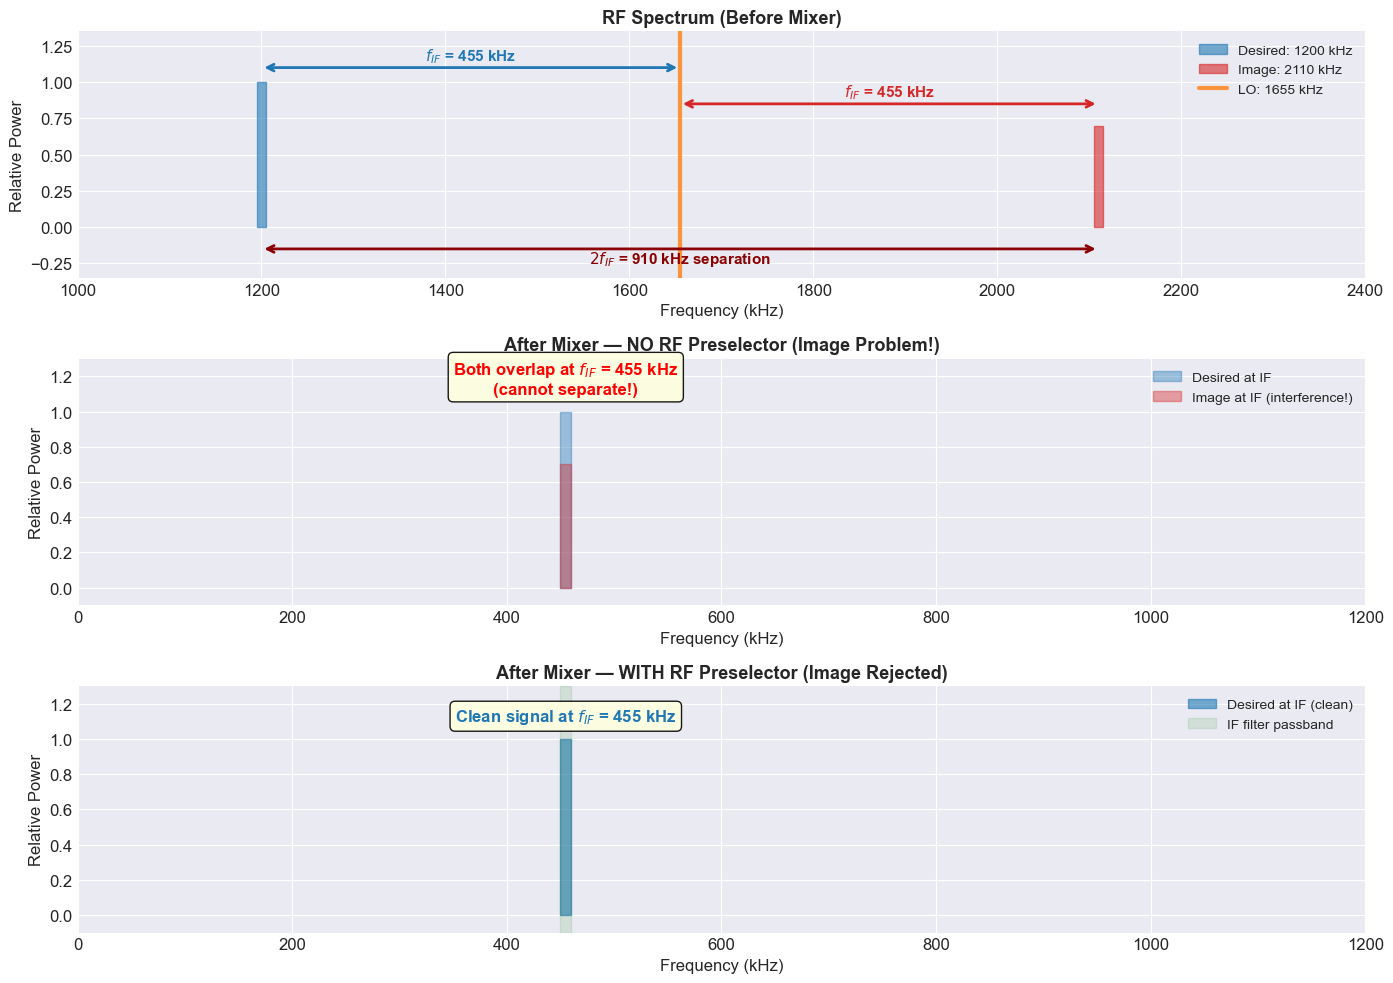

Superheterodyne Receiver (HW2 Problem 9 parameters):
  Desired station:    f_RF    = 1200 kHz
  Intermediate freq:  f_IF    = 455 kHz
  Local oscillator:   f_LO    = f_RF + f_IF = 1655 kHz
  Image frequency:    f_image = f_RF + 2f_IF = 2110 kHz
  Image separation:   2f_IF   = 910 kHz

Image problem: A signal at 2110 kHz also mixes to 455 kHz IF!
  f_LO - f_image = 1655 - 2110 = -455 kHz => |f_IF|

Mitigation strategies:
  1. RF preselector filter (bandpass centered on f_RF)
  2. Higher IF (increases image separation: 2f_IF)
  3. Double conversion (two IF stages)


In [6]:
# =============================================================================
# Section 5: Superheterodyne Receiver — Frequency Domain Visualization
# =============================================================================
# HW2 Problem 9 parameters
f_IF = 455e3      # IF frequency (Hz)
f_RF = 1200e3     # Desired station (Hz)
f_LO = f_RF + f_IF  # Local oscillator
f_image = f_RF + 2 * f_IF  # Image frequency

# Channel bandwidth (AM broadcast)
BW_ch = 10e3  # 10 kHz AM channel

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# --- Panel 1: RF spectrum (before mixer) ---
ax = axes[0]
# Desired signal
ax.fill_between([(f_RF - BW_ch/2)/1e3, (f_RF + BW_ch/2)/1e3], 0, 1,
                color='C0', alpha=0.6, label=f'Desired: {f_RF/1e3:.0f} kHz')
# Image signal
ax.fill_between([(f_image - BW_ch/2)/1e3, (f_image + BW_ch/2)/1e3], 0, 0.7,
                color='C3', alpha=0.6, label=f'Image: {f_image/1e3:.0f} kHz')
# LO
ax.axvline(f_LO/1e3, color='C1', linestyle='-', linewidth=3, alpha=0.8,
           label=f'LO: {f_LO/1e3:.0f} kHz')
# Annotations
ax.annotate('', xy=(f_RF/1e3, 1.1), xytext=(f_LO/1e3, 1.1),
            arrowprops=dict(arrowstyle='<->', color='C0', lw=2))
ax.text((f_RF + f_LO)/2/1e3, 1.15, f'$f_{{IF}}$ = {f_IF/1e3:.0f} kHz',
        ha='center', fontsize=11, color='C0', fontweight='bold')
ax.annotate('', xy=(f_LO/1e3, 0.85), xytext=(f_image/1e3, 0.85),
            arrowprops=dict(arrowstyle='<->', color='C3', lw=2))
ax.text((f_LO + f_image)/2/1e3, 0.9, f'$f_{{IF}}$ = {f_IF/1e3:.0f} kHz',
        ha='center', fontsize=11, color='C3', fontweight='bold')
ax.annotate('', xy=(f_RF/1e3, -0.15), xytext=(f_image/1e3, -0.15),
            arrowprops=dict(arrowstyle='<->', color='darkred', lw=2))
ax.text((f_RF + f_image)/2/1e3, -0.25, f'$2f_{{IF}}$ = {2*f_IF/1e3:.0f} kHz separation',
        ha='center', fontsize=11, color='darkred', fontweight='bold')
ax.set_xlim(1000, 2400)
ax.set_ylim(-0.35, 1.35)
ax.set_xlabel('Frequency (kHz)')
ax.set_ylabel('Relative Power')
ax.set_title('RF Spectrum (Before Mixer)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')

# --- Panel 2: After mixer (without RF preselector) ---
ax = axes[1]
# Both signals land at IF
ax.fill_between([(f_IF - BW_ch/2)/1e3, (f_IF + BW_ch/2)/1e3], 0, 1,
                color='C0', alpha=0.4, label=f'Desired at IF')
ax.fill_between([(f_IF - BW_ch/2)/1e3, (f_IF + BW_ch/2)/1e3], 0, 0.7,
                color='C3', alpha=0.4, label=f'Image at IF (interference!)')
ax.set_xlim(0, 1200)
ax.set_ylim(-0.1, 1.3)
ax.set_xlabel('Frequency (kHz)')
ax.set_ylabel('Relative Power')
ax.set_title('After Mixer — NO RF Preselector (Image Problem!)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.text(f_IF/1e3, 1.1, f'Both overlap at $f_{{IF}}$ = {f_IF/1e3:.0f} kHz\n(cannot separate!)',
        ha='center', fontsize=12, color='red', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

# --- Panel 3: With RF preselector ---
ax = axes[2]
# Only desired signal passes RF filter
ax.fill_between([(f_IF - BW_ch/2)/1e3, (f_IF + BW_ch/2)/1e3], 0, 1,
                color='C0', alpha=0.6, label='Desired at IF (clean)')
# IF filter passband
ax.axvspan((f_IF - BW_ch/2)/1e3, (f_IF + BW_ch/2)/1e3,
           alpha=0.1, color='green', label='IF filter passband')
ax.set_xlim(0, 1200)
ax.set_ylim(-0.1, 1.3)
ax.set_xlabel('Frequency (kHz)')
ax.set_ylabel('Relative Power')
ax.set_title('After Mixer — WITH RF Preselector (Image Rejected)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.text(f_IF/1e3, 1.1, f'Clean signal at $f_{{IF}}$ = {f_IF/1e3:.0f} kHz',
        ha='center', fontsize=12, color='C0', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.tight_layout()
plt.show()

print("Superheterodyne Receiver (HW2 Problem 9 parameters):")
print(f"  Desired station:    f_RF    = {f_RF/1e3:.0f} kHz")
print(f"  Intermediate freq:  f_IF    = {f_IF/1e3:.0f} kHz")
print(f"  Local oscillator:   f_LO    = f_RF + f_IF = {f_LO/1e3:.0f} kHz")
print(f"  Image frequency:    f_image = f_RF + 2f_IF = {f_image/1e3:.0f} kHz")
print(f"  Image separation:   2f_IF   = {2*f_IF/1e3:.0f} kHz")
print(f"\nImage problem: A signal at {f_image/1e3:.0f} kHz also mixes to {f_IF/1e3:.0f} kHz IF!")
print(f"  f_LO - f_image = {f_LO/1e3:.0f} - {f_image/1e3:.0f} = -{f_IF/1e3:.0f} kHz => |f_IF|")
print(f"\nMitigation strategies:")
print(f"  1. RF preselector filter (bandpass centered on f_RF)")
print(f"  2. Higher IF (increases image separation: 2f_IF)")
print(f"  3. Double conversion (two IF stages)")

## Summary

### Key Formulas

| Quantity | Formula |
|----------|--------|
| OOK signal (bit 1) | $s(t) = A\cos(2\pi f_c t)$ |
| OOK signal (bit 0) | $s(t) = 0$ |
| Bit duration | $T_b = 1/R_b$ |
| Baseband first-null BW | $B = R_b$ |
| ASK null-to-null BW | $2R_b = 2B$ |
| AM null-to-null BW | $2B$ |
| Superhet LO freq | $f_{\text{LO}} = f_{\text{RF}} + f_{\text{IF}}$ |
| Image frequency | $f_{\text{image}} = f_{\text{RF}} + 2f_{\text{IF}}$ |

### Key Takeaways

1. **ASK is the digital counterpart to AM** — both encode information in the carrier amplitude
2. **OOK** is the simplest ASK: carrier on (bit 1) or off (bit 0)
3. **Baseband bandwidth $B = R_b$**; modulation doubles this to **ASK bandwidth $= 2R_b = 2B$** (same relationship as AM)
4. **Demodulation** can be coherent (multiply + filter + threshold) or non-coherent (envelope detector)
5. **Superheterodyne** receiver converts RF to fixed IF for easier filtering and amplification
6. **Image frequency** $f_{\text{image}} = f_{\text{RF}} + 2f_{\text{IF}}$ is the key design concern

### HW2 Connections
- **Problem 6:** OOK waveform sketch (Section 1 worked example)
- **Problem 7:** ASK spectral analysis and bandwidth (Section 2)
- **Problem 8:** AM vs ASK comparison (Section 3)
- **Problem 9:** Superheterodyne receiver design (Section 5)
- **Problem 10:** AM power/efficiency (review Lesson 5 notebook)

### Next Lesson
- **Lesson 7 (Thursday):** Reading Quiz 3, Python Lab 2 (AM/ASK), SSB Introduction, W3USR HF Station Tour
- **Homework 2 due Thursday**